<a href="https://colab.research.google.com/github/taponjou/SudokuXYZ/blob/main/projet_sci_1402.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import os
import kagglehub
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("algozee/financial-transaction-fraud-dataset")

print("Path to dataset files:", path)

df = pd.read_csv(os.path.join(path, "FraudShield_Banking_Data.csv"))
print(f'Number of rows: {df.shape[0]} | Number of columns:{df.shape[1]} ')
print(f"Fraud Label : {df['Fraud_Label'].value_counts(normalize=True)}")
df.head(3)

Using Colab cache for faster access to the 'financial-transaction-fraud-dataset' dataset.
Path to dataset files: /kaggle/input/financial-transaction-fraud-dataset
Number of rows: 50000 | Number of columns:25 
Fraud Label : Fraud_Label
Normal    0.951536
Fraud     0.048464
Name: proportion, dtype: float64


,Transaction_ID,Customer_ID,Transaction_Amount (in Million),Transaction_Time,Transaction_Date,Transaction_Type,Merchant_ID,Merchant_Category,Transaction_Location,Customer_Home_Location,...,Daily_Transaction_Count,Weekly_Transaction_Count,Avg_Transaction_Amount (in Million),Max_Transaction_Last_24h (in Million),Is_International_Transaction,Is_New_Merchant,Failed_Transaction_Count,Unusual_Time_Transaction,Previous_Fraud_Count,Fraud_Label
0,431438.0,24239.0,6.0,10:54,2025-03-08,POS,97028.0,ATM,Singapore,Lahore,...,4.0,17.0,2.0,4.0,Yes,Yes,0.0,No,1.0,Normal
1,902451.0,77250.0,9.0,19:23,2025-01-17,ATM,27515.0,ATM,Singapore,Lahore,...,4.0,9.0,5.0,8.0,Yes,Yes,1.0,No,1.0,Normal
2,223410.0,34294.0,3.0,10:20,2025-04-30,POS,13810.0,Electronics,Faisalabad,Faisalabad,...,5.0,18.0,5.0,8.0,Yes,No,0.0,Yes,1.0,Normal


Extraction des données numériques et catégorielle

In [21]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])
categorical_df = df.select_dtypes(include=['object'])
categorical_df.head(5)

,Transaction_Time,Transaction_Date,Transaction_Type,Merchant_Category,Transaction_Location,Customer_Home_Location,IP_Address,Card_Type,Is_International_Transaction,Is_New_Merchant,Unusual_Time_Transaction,Fraud_Label
0,10:54,2025-03-08,POS,ATM,Singapore,Lahore,231.92.159.84,Credit,Yes,Yes,No,Normal
1,19:23,2025-01-17,ATM,ATM,Singapore,Lahore,140.98.205.212,Credit,Yes,Yes,No,Normal
2,10:20,2025-04-30,POS,Electronics,Faisalabad,Faisalabad,199.72.40.86,Debit,Yes,No,Yes,Normal
3,14:11,2025-02-21,Online,Grocery,London,Karachi,209.30.4.37,Debit,No,Yes,Yes,Normal
4,04:12,2025-04-11,Online,Electronics,Singapore,Islamabad,73.140.112.60,Debit,No,Yes,No,Normal


Inspection des valeurs nulles dans les variables numerics

In [22]:
numeric_df.isnull().sum().sort_values(ascending=False)

,0
Failed_Transaction_Count,11
Customer_ID,10
Transaction_Amount (in Million),9
Device_ID,9
Daily_Transaction_Count,9
Avg_Transaction_Amount (in Million),9
Account_Balance (in Million),9
Merchant_ID,7
Weekly_Transaction_Count,5
Max_Transaction_Last_24h (in Million),4


Verifions le pourcentage des valeurs manquantes

In [23]:
(numeric_df.isnull().sum() / len(numeric_df) * 100).sort_values(ascending=False)

,0
Failed_Transaction_Count,0.022
Customer_ID,0.020
Transaction_Amount (in Million),0.018
Device_ID,0.018
Daily_Transaction_Count,0.018
Avg_Transaction_Amount (in Million),0.018
Account_Balance (in Million),0.018
Merchant_ID,0.014
Weekly_Transaction_Count,0.010
Max_Transaction_Last_24h (in Million),0.008


Visualisation des valeurs manuantes

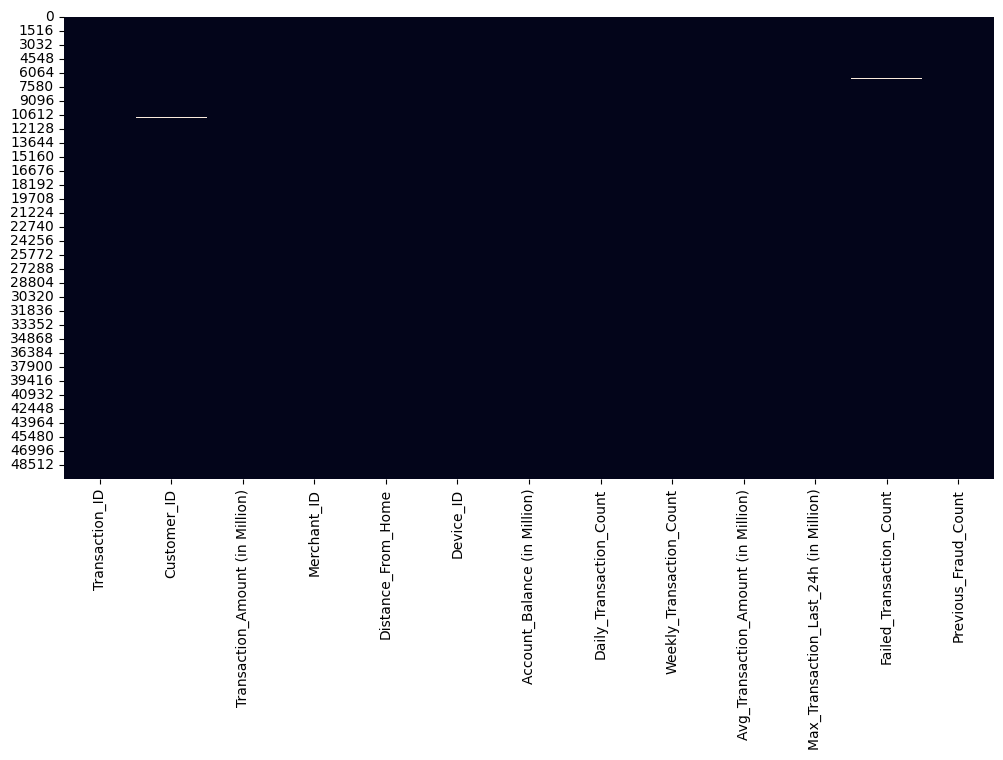

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(numeric_df.isnull(), cbar=False)
plt.show()

Étant donné que la proportion de valeurs manquantes est négligeable par rapport au nombre total d'observations, l'imputation par la moyenne a été retenue. Cette approche permet de préserver l'ensemble des données tout en minimisant le risque d'introduire un biais significatif dans l'analyse.

Imputation de ces vaviablr par la moyenne

In [18]:
for col in numeric_df.columns:
    numeric_df[col] = numeric_df[col].fillna(numeric_df[col].mean())

,0
Transaction_ID,0
Customer_ID,0
Transaction_Amount (in Million),0
Merchant_ID,0
Distance_From_Home,0
Device_ID,0
Account_Balance (in Million),0
Daily_Transaction_Count,0
Weekly_Transaction_Count,0
Avg_Transaction_Amount (in Million),0
